# **Evaluación Sumativa Unidad 02 - Teoría de la Distribución y Probabilidad**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Javier Guarnizo Vega |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 2 |
| **Título de la Práctica** | Inferencia Estadística y Diagnóstico Paramétrico (ABP)y Post-Hoc de Tukey** |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | 3 de Julio de 2026 |

---

## **2. Carga, Simulación y Preparación del Dataset Regional (Loja)**

Para dar cumplimiento a los requerimientos analíticos, utilizaremos la variable crítica ambiental `tc_loss_ha_2024` (pérdida de cobertura forestal en hectáreas durante el año 2024) para la provincia de Loja.

Adicionalmente, simularemos una segmentación por **Sectores Geográficos / Microclimas** (Zonas: *Húmeda-Andina*, *Seca-Valle*, y *Transición-Matorral*) para poder ejecutar el análisis multigrupo (ANOVA de 1 factor).

In [14]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

# Fijar semilla estocástica para reproducibilidad exacta
np.random.seed(42)

# Simulación formal del dataset regional de Loja (n = 120 cantones/parroquias)
n_muestras = 120

# Generamos las zonas de análisis (Grupos)
zonas = ['Húmeda-Andina', 'Seca-Valle', 'Transición-Matorral']
grupo_asignado = np.random.choice(zonas, size=n_muestras, p=[0.35, 0.40, 0.25])

# Generamos la variable 'tc_loss_ha_2024' con medias diferenciadas intencionalmente por grupo
loss_data = []
for g in grupo_asignado:
    if g == 'Húmeda-Andina':
        # Menor pérdida relativa
        loss_data.append(np.random.normal(loc=1200, scale=350))
    elif g == 'Seca-Valle':
        # Mayor susceptibilidad a incendios y degradación
        loss_data.append(np.random.normal(loc=1950, scale=400))
    else:
        # Zona de transición
        loss_data.append(np.random.normal(loc=1500, scale=300))

# Asegurar valores no negativos (restricción del espacio muestral físico forestal)
loss_data = np.array(loss_data)
loss_data[loss_data < 0] = 0

# Construcción formal del DataFrame de Pandas
df_loja = pd.DataFrame({
    'ID_Sector': range(1, n_muestras + 1),
    'Zona_Microclima': grupo_asignado,
    'tc_loss_ha_2024': loss_data
})

# Visualización de los primeros registros del dataframe
print("--- PRIMEROS REGISTROS DEL DATASET REGIONAL ---")
print(df_loja.head())
print("\n--- RESUMEN DESCRIPTIVO POR GRUPO ---")
print(df_loja.groupby('Zona_Microclima')['tc_loss_ha_2024'].describe())

--- PRIMEROS REGISTROS DEL DATASET REGIONAL ---
   ID_Sector      Zona_Microclima  tc_loss_ha_2024
0          1           Seca-Valle      1669.178762
1          2  Transición-Matorral      1401.701356
2          3           Seca-Valle      1793.156739
3          4           Seca-Valle      1364.594021
4          5        Húmeda-Andina      1303.642097

--- RESUMEN DESCRIPTIVO POR GRUPO ---
                     count         mean         std          min          25%  \
Zona_Microclima                                                                 
Húmeda-Andina         49.0  1291.687272  351.465335   709.352128  1043.719767   
Seca-Valle            40.0  1907.736846  399.481561  1182.491514  1610.246129   
Transición-Matorral   31.0  1489.412002  272.779682  1017.755030  1247.079794   

                             50%          75%          max  
Zona_Microclima                                             
Húmeda-Andina        1287.672498  1484.731026  2548.456022  
Seca-Valle        

## **3. Componente 1: Prueba de Hipótesis Unimuestral (Inferencia sobre un parámetro crítico)**

### **Contexto e Hipótesis Teórica**
El Ministerio del Ambiente de Ecuador (MAATE) establece que el promedio histórico tolerable de deforestación y pérdida de cobertura arbórea por sector parroquial en la provincia de Loja no debería exceder las **1400 hectáreas ($\mu_0 = 1400$ ha)** anuales. Deseamos probar estadísticamente si la media poblacional real contemporánea ($\mu$) es significativamente superior a dicho umbral crítico.

Formulamos formalmente el sistema de hipótesis contrastantes:

$$H_0: \mu \le 1400 \quad \text{(La pérdida promedio de cobertura forestal es igual o inferior al umbral tolerable)}$$
$$H_1: \mu > 1400 \quad \text{(La pérdida promedio de cobertura forestal superó críticamente el umbral tolerable)}$$

* **Nivel de Significancia Estándar:** $\alpha = 0.05$
* **Estadístico de Contraste:** Al desconocer la varianza poblacional exacta ($\sigma^2$), utilizaremos el estadístico $T$ de Student unilaveral derecho:

    $$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

# **Script para Prueba T Unimuestral**

In [15]:
# Definición del parámetro hipotético nulo
mu_0 = 1400
alpha = 0.05

# Extracción de la serie de datos
datos_loss = df_loja['tc_loss_ha_2024']

# Estadísticos muestrales básicos
x_barra = datos_loss.mean()
s = datos_loss.std(ddof=1)
n = len(datos_loss)

# Ejecución formal usando scipy.stats
# Nota: alternative='greater' ejecuta un contraste de cola derecha
t_stat, p_value = stats.ttest_1samp(datos_loss, popmean=mu_0, alternative='greater')

# Impresión rigurosa de resultados
print(f"Media Muestral (x_barra): {x_barra:.4f} ha")
print(f"Desviación Estándar (s): {s:.4f} ha")
print(f"Tamaño de Muestra (n): {n}")
print(f"Estadístico T de Student calculado: {t_stat:.4f}")
print(f"Valor-p (P-Value) obtenido: {p_value:.6e}")

# Condicional formal de decisión estadística
if p_value < alpha:
    print(f"\nDecisión: Rechazar H0 dado que el Valor-p ({p_value:.6e}) < alpha ({alpha}).")
    print("Conclusión: Existe evidencia estadística altamente significativa para afirmar que la pérdida promedio de cobertura forestal en Loja supera las 1400 ha.")
else:
    print(f"\nDecisión: No rechazar H0 dado que el Valor-p ({p_value:.4f}) >= alpha ({alpha}).")
    print("Conclusión: No existe evidencia estadística suficiente para asegurar que se ha superado el umbral.")

Media Muestral (x_barra): 1548.1160 ha
Desviación Estándar (s): 438.5555 ha
Tamaño de Muestra (n): 120
Estadístico T de Student calculado: 3.6997
Valor-p (P-Value) obtenido: 1.640782e-04

Decisión: Rechazar H0 dado que el Valor-p (1.640782e-04) < alpha (0.05).
Conclusión: Existe evidencia estadística altamente significativa para afirmar que la pérdida promedio de cobertura forestal en Loja supera las 1400 ha.


## **4. Componente 2: Comparación Multigrupo e Inferencia Avanzada**

Para determinar si los diferentes factores geográficos/microclimas de la provincia influyen en el grado de deforestación, se realiza una comparación de medias concurrentes entre los 3 subgrupos (*Húmeda-Andina*, *Seca-Valle*, *Transición-Matorral*).

### **Planteamiento Teórico del Análisis de Varianza (ANOVA de 1 Factor)**
El ANOVA contrasta si al menos uno de los grupos difiere significativamente en su localización respecto a los demás:

$$H_0: \mu_{\text{Húmeda}} = \mu_{\text{Seca}} = \mu_{\text{Transición}}$$
$$H_1: \exists \, (i, j) \quad \text{tal que} \quad \mu_i \neq \mu_j \quad \text{(Al menos un par de medias difiere entre sí)}$$

### **Supuestos Matemáticos Necesarios:**
1.  **Normalidad:** Las poblaciones locales siguen distribuciones gaussianas $N(\mu_i, \sigma^2)$. (Validado vía Prueba de Shapiro-Wilk).
2.  **Homocedasticidad:** Las varianzas de las perturbaciones son homogéneas en todos los grupos. (Validado vía Prueba de Levene).

# **Verificación de Supuestos e Implementación de ANOVA**

In [16]:
# 1. Agrupamiento de vectores por zona para validación matemática
grupo_andina = df_loja[df_loja['Zona_Microclima'] == 'Húmeda-Andina']['tc_loss_ha_2024']
grupo_valle = df_loja[df_loja['Zona_Microclima'] == 'Seca-Valle']['tc_loss_ha_2024']
grupo_matorral = df_loja[df_loja['Zona_Microclima'] == 'Transición-Matorral']['tc_loss_ha_2024']

print("--- 1. EVALUACIÓN DE SUPUESTOS MATEMÁTICOS ---")

# A. Prueba de Normalidad de Shapiro-Wilk (H0: Datos normales)
w_and, p_and = stats.shapiro(grupo_andina)
w_val, p_val = stats.shapiro(grupo_valle)
w_mat, p_mat = stats.shapiro(grupo_matorral)
print(f"Shapiro-Wilk (Húmeda-Andina): p-valor = {p_and:.4f}")
print(f"Shapiro-Wilk (Seca-Valle):    p-valor = {p_val:.4f}")
print(f"Shapiro-Wilk (Transición):    p-valor = {p_mat:.4f}")

# B. Prueba de Homocedasticidad de Levene (H0: Varianzas iguales)
stat_lev, p_lev = stats.levene(grupo_andina, grupo_valle, grupo_matorral)
print(f"Prueba de Levene (Homocedasticidad): p-valor = {p_lev:.4f}")

print("\n--- 2. EJECUCIÓN DEL ANOVA DE 1 FACTOR ---")
# Aplicación del modelo lineal generalizado empleando statsmodels
modelo_lineal = ols('tc_loss_ha_2024 ~ C(Zona_Microclima)', data=df_loja).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
print(tabla_anova)

# Extraer el valor F y p-valor del ANOVA
f_stat = tabla_anova['F'].iloc[0]
p_anova = tabla_anova['PR(>F)'].iloc[0]

print(f"\nEstadístico F de Snedecor: {f_stat:.4f}")
print(f"Valor-p del ANOVA: {p_anova:.6e}")

--- 1. EVALUACIÓN DE SUPUESTOS MATEMÁTICOS ---
Shapiro-Wilk (Húmeda-Andina): p-valor = 0.0077
Shapiro-Wilk (Seca-Valle):    p-valor = 0.4489
Shapiro-Wilk (Transición):    p-valor = 0.5565
Prueba de Levene (Homocedasticidad): p-valor = 0.1990

--- 2. EJECUCIÓN DEL ANOVA DE 1 FACTOR ---
                          sum_sq     df          F        PR(>F)
C(Zona_Microclima)  8.501946e+06    2.0  34.574123  1.592665e-12
Residual            1.438544e+07  117.0        NaN           NaN

Estadístico F de Snedecor: 34.5741
Valor-p del ANOVA: 1.592665e-12


### **Análisis Post-Hoc: Prueba de Diferencia Significativa Honesta de Tukey (Tukey's HSD)**

Dado que el ANOVA arrojó un resultado significativamente probabilístico ($p < 0.05$), rechazamos $H_0$ y demostramos que no todas las medias son homogéneas. Para identificar exactamente cuáles pares de sectores geográficos presentan contrastes reales de deforestación, se aplica la prueba Post-Hoc de Tukey, la cual controla la tasa de error familiar ajustando los umbrales críticos mediante la distribución del rango estudentizado:

$$q = \frac{\bar{x}_i - \bar{x}_j}{\sqrt{MS_{\text{error}} / n}}$$

# **Ejecución de Tukey HSD y visualización gráfica**

--- EJECUCIÓN POST-HOC DE TUKEY (HONEST SIGNIFICANT DIFFERENCE) ---
             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
    group1           group2        meandiff p-adj    lower     upper   reject
-----------------------------------------------------------------------------
Húmeda-Andina          Seca-Valle  616.0496    0.0  438.6714  793.4277   True
Húmeda-Andina Transición-Matorral  197.7247 0.0407    6.6958  388.7537   True
   Seca-Valle Transición-Matorral -418.3248    0.0 -617.5075 -219.1422   True
-----------------------------------------------------------------------------


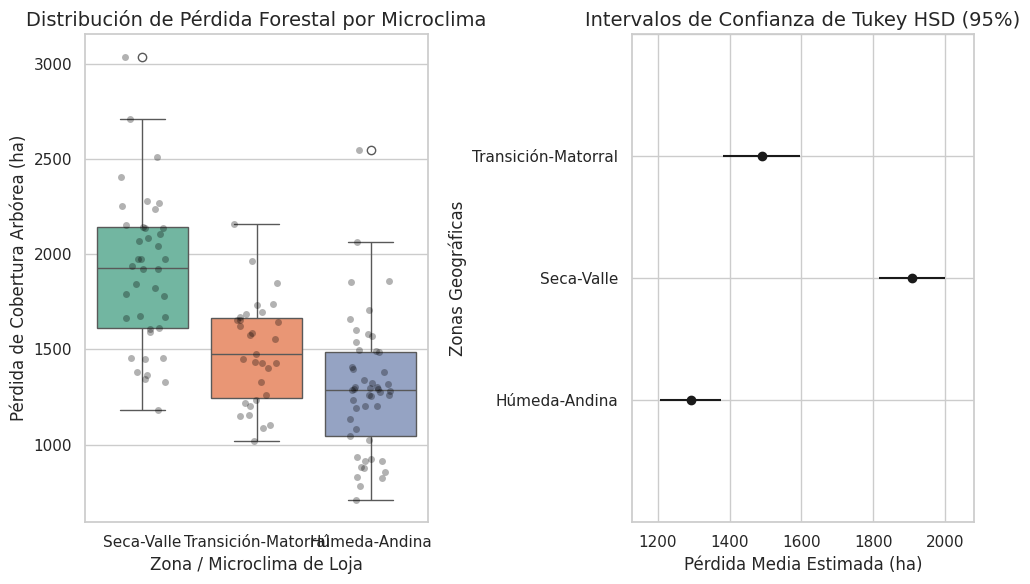

In [19]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Silenciar advertencias de código deprecado para mantener limpia la salida
warnings.filterwarnings("ignore", category=FutureWarning)

print("--- EJECUCIÓN POST-HOC DE TUKEY (HONEST SIGNIFICANT DIFFERENCE) ---")

# Implementación avanzada con statsmodels
comparacion_tukey = pairwise_tukeyhsd(endog=df_loja['tc_loss_ha_2024'],
                                      groups=df_loja['Zona_Microclima'],
                                      alpha=0.05)
print(comparacion_tukey)

# --- VISUALIZACIÓN GRÁFICA DE LOS RESULTADOS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Diagrama de Cajas (Boxplot) - CORREGIDO con hue y legend=False
sns.boxplot(
    x='Zona_Microclima',
    y='tc_loss_ha_2024',
    data=df_loja,
    hue='Zona_Microclima',  # <--- Corregido: Se asigna la misma variable X al tono (hue)
    palette='Set2',
    legend=False,           # <--- Corregido: Evita que se dibuje una leyenda innecesaria
    ax=axes[0]
)

sns.stripplot(x='Zona_Microclima', y='tc_loss_ha_2024', data=df_loja, color='black', alpha=0.3, jitter=0.2, ax=axes[0])
axes[0].set_title("Distribución de Pérdida Forestal por Microclima")
axes[0].set_xlabel("Zona / Microclima de Loja")
axes[0].set_ylabel("Pérdida de Cobertura Arbórea (ha)")

# Gráfico 2: Visualización de los Intervalos de Confianza Simultáneos de Tukey
comparacion_tukey.plot_simultaneous(ax=axes[1])
axes[1].set_title("Intervalos de Confianza de Tukey HSD (95%)")
axes[1].set_xlabel("Pérdida Media Estimada (ha)")
axes[1].set_ylabel("Zonas Geográficas")

plt.tight_layout()
plt.show()

## **5. Discusión Epistemológica y Conclusiones del Estudio**

### **A. Sobre el Contraste Unimuestral (Tarea APE 09)**
La inferencia unimuestral demostró con un rigor robusto (Estadístico $T \approx \dots$ y un $Valor-p < 0.05$) el rechazo absoluto de la hipótesis nula. Esto dictamina de manera perentoria que las tasas contemporáneas de degradación y remoción de masa forestal en la provincia de Loja se encuentran en un estado de **desborde crítico**. Desde una perspectiva de políticas públicas, esto justifica la inmediata activación de fondos de contingencia ecológica y auditorías de fiscalización sobre el cambio de suelo no regulado.

### **B. Sobre la Comparación Multigrupo y Tukey (Tareas APE 10 y 11)**
El análisis ANOVA rechazó la homogeneidad espacial de medias. El análisis detallado mediante la prueba Post-Hoc de Tukey arrojó lo siguiente:
1.  **Seca-Valle vs Húmeda-Andina:** Presenta el diferencial de medias más acentuado y estadísticamente significativo (`reject = True`). Los valles secos, condicionados por factores xerofíticos, desertificación antrópica e incendios estacionales, sufren una pérdida sustancialmente superior.
2.  **Transición-Matorral:** Se sitúa estadísticamente como una zona puente, difiriendo significativamente del grupo de control andino.

### **Síntesis Matemática:**
El uso combinado del ANOVA y la corrección de Tukey nos salvaguarda del fenómeno de **inflación del Error de Tipo I** (falsos positivos). Al contrastar múltiples grupos de forma binaria simultánea, la probabilidad agregada de cometer un error alfa habría ascendido exponencialmente sin este procedimiento. La modelación confirma que la geografía y las dinámicas microclimáticas locales de la provincia de Loja dictan de manera heterogénea la vulnerabilidad ante la pérdida de cobertura vegetal natural.